# PFM-xLSTM-MIL (Final Structured Notebook)

This notebook is a clean, production-style pipeline for training PFM-xLSTM-MIL on real CAMELYON16 features.

## 1) Environment and Imports

In [1]:
!pip -q install timm h5py scikit-learn matplotlib hilbertsfc huggingface_hub pandas
!pip -q install git+https://github.com/NX-AI/xlstm
!test -d /content/vision-lstm || git clone -q https://github.com/NX-AI/vision-lstm /content/vision-lstm

import os
import sys
import re
import math
import random
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset

for p in ["/content/vision-lstm", "/content/vision-lstm/src", "/content/xlstm"]:
    if os.path.exists(p) and p not in sys.path:
        sys.path.insert(0, p)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.4/357.4 kB 24.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 102.1 MB/s eta 0:00:00
Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2) Download Dataset from Hugging Face

If dataset is gated, make sure your `HF_TOKEN` is stored in Colab Secrets and accessible.

In [2]:
from huggingface_hub import snapshot_download
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
HF_REPO = "kaczmarj/camelyon16-uni"
DATA_ROOT = Path("/content/camelyon16_uni_data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

local_repo = Path(
    snapshot_download(
        repo_id=HF_REPO,
        repo_type="dataset",
        token=HF_TOKEN,
        local_dir=str(DATA_ROOT),
    )
)

EMBED_DIR = local_repo / "embeddings"
PATCH_DIR = local_repo / "patches"
PROCESS_CSV = PATCH_DIR / "process_list_autogen.csv"

print("Repo root:", local_repo)
print("Embeddings dir:", EMBED_DIR)
print("Patches dir:", PATCH_DIR)
print("Manifest:", PROCESS_CSV)
print("#pt:", len(list(EMBED_DIR.glob("*.pt"))))
print("#h5:", len(list(PATCH_DIR.rglob("*.h5"))))


Fetching ... files: 0it [00:00, ?it/s]

Repo root: /content/camelyon16_uni_data
Embeddings dir: /content/camelyon16_uni_data/embeddings
Patches dir: /content/camelyon16_uni_data/patches
Manifest: /content/camelyon16_uni_data/patches/process_list_autogen.csv
#pt: 399
#h5: 399


## 3) Real Dataset Loader with Hilbert Sorting

This loader:
- pairs `.pt` features and `.h5` coords robustly,
- infers labels from slide names (`normal`/`tumor`),
- applies Hilbert sorting,
- enforces fixed token length (`MAX_TOKENS`) for xLSTM stability.

In [3]:
MAX_TOKENS = 10_000

def _norm_id(s):
    s = str(s).strip().lower()
    s = Path(s).stem
    return re.sub(r"[^a-z0-9]+", "", s)

def infer_label_from_slide_id(slide_id_stem):
    s = slide_id_stem.lower()
    if "tumor" in s:
        return 1
    if "normal" in s:
        return 0
    return None

def _xy2d(n_side, x, y):
    d = 0
    s = n_side // 2
    while s > 0:
        rx = 1 if (x & s) else 0
        ry = 1 if (y & s) else 0
        d += s * s * ((3 * rx) ^ ry)
        if ry == 0:
            if rx == 1:
                x = n_side - 1 - x
                y = n_side - 1 - y
            x, y = y, x
        s //= 2
    return d

def hilbert_indices(coords_np):
    try:
        import hilbertsfc
        mx = int(coords_np.max()) if coords_np.size else 0
        p = max(1, int(math.ceil(math.log2(mx + 1))))
        if hasattr(hilbertsfc, "hilbert_index"):
            return np.array([hilbertsfc.hilbert_index(int(x), int(y), p=p) for x, y in coords_np], dtype=np.int64)
        if hasattr(hilbertsfc, "encode"):
            try:
                return np.array(hilbertsfc.encode(coords_np.astype(np.int64)), dtype=np.int64)
            except Exception:
                return np.array(hilbertsfc.encode(coords_np.astype(np.int64).T), dtype=np.int64)
    except Exception:
        pass
    mx = int(coords_np.max()) if coords_np.size else 0
    p = max(1, int(math.ceil(math.log2(mx + 1))))
    n_side = 1 << p
    return np.array([_xy2d(n_side, int(x), int(y)) for x, y in coords_np.astype(np.int64)], dtype=np.int64)

class WSIFeatureDataset(Dataset):
    def __init__(self, embed_dir, patch_dir, process_csv, max_tokens=10_000):
        self.embed_dir = Path(embed_dir)
        self.patch_dir = Path(patch_dir)
        self.max_tokens = max_tokens

        df = pd.read_csv(process_csv)
        if "slide_id" not in df.columns:
            raise ValueError(f"'slide_id' missing. Columns: {list(df.columns)}")

        pt_files = sorted(self.embed_dir.glob("*.pt"))
        h5_files = sorted(self.patch_dir.rglob("*.h5"))
        pt_map = {_norm_id(p.stem): p for p in pt_files}
        h5_map = {_norm_id(p.stem): p for p in h5_files}

        self.samples = []
        for _, row in df.iterrows():
            sid_stem = Path(str(row["slide_id"]).strip()).stem
            label = infer_label_from_slide_id(sid_stem)
            if label is None:
                continue
            key = _norm_id(sid_stem)
            pt_path = pt_map.get(key)
            h5_path = h5_map.get(key)
            if pt_path is None or h5_path is None:
                continue
            self.samples.append((sid_stem, pt_path, h5_path, int(label)))

        if len(self.samples) == 0:
            raise RuntimeError("No matched samples found after pairing manifest <-> pt <-> h5")

        y = np.array([s[3] for s in self.samples], dtype=np.int64)
        print(f"Loaded {len(self.samples)} slides | normal={(y==0).sum()} tumor={(y==1).sum()}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sid, pt_path, h5_path, label = self.samples[idx]
        feats = torch.load(pt_path, map_location="cpu")
        if isinstance(feats, dict):
            feats = feats["features"] if "features" in feats else next(iter(feats.values()))
        feats = torch.as_tensor(feats, dtype=torch.float32)
        if feats.ndim != 2:
            raise ValueError(f"{sid}: expected 2D features, got {tuple(feats.shape)}")

        with h5py.File(h5_path, "r") as f:
            if "coords" in f:
                coords = f["coords"][:]
            else:
                coords = None
                for k in f.keys():
                    arr = f[k][:]
                    if arr.ndim == 2 and arr.shape[1] == 2:
                        coords = arr
                        break
                if coords is None:
                    raise KeyError(f"{sid}: no coordinate dataset (N,2) found")

        coords = np.asarray(coords, dtype=np.int64)
        n = min(feats.shape[0], coords.shape[0])
        if n == 0:
            raise RuntimeError(f"{sid}: empty bag after alignment")

        feats = feats[:n]
        coords = coords[:n]
        order = np.argsort(hilbert_indices(coords))
        feats = feats[torch.from_numpy(order)]

        if feats.shape[0] >= self.max_tokens:
            feats = feats[:self.max_tokens]
        else:
            pad = self.max_tokens - feats.shape[0]
            feats = torch.cat([feats, torch.zeros(pad, feats.shape[1], dtype=feats.dtype)], dim=0)

        y = torch.tensor([float(label)], dtype=torch.float32)
        return {"slide_id": sid, "features": feats, "label": y}

dataset = WSIFeatureDataset(EMBED_DIR, PATCH_DIR, PROCESS_CSV, max_tokens=MAX_TOKENS)
FEATURE_DIM = dataset[0]["features"].shape[1]
print("Detected feature dim:", FEATURE_DIM)
ex = dataset[0]
print("Example:", ex["slide_id"], tuple(ex["features"].shape), ex["label"].item())


Loaded 270 slides | normal=159 tumor=111
Detected feature dim: 1024
Example: normal_001 (10000, 1024) 0.0


## 4) Model Definition (Input Dim from Dataset)

In [4]:
import importlib

def resolve_mlstm_block_factory(hidden_dim=512, context_length=10_000):
    candidates = [
        ("xlstm.blocks.mlstm.block", "mLSTMBlock", "mLSTMBlockConfig"),
        ("vislstm.modules.xlstm.blocks.mlstm.block", "mLSTMBlock", "mLSTMBlockConfig"),
        ("vision_lstm.vision_lstm2", "mLSTMBlock", "mLSTMBlockConfig"),
    ]
    errors = []
    for mod_name, cls_name, cfg_name in candidates:
        try:
            mod = importlib.import_module(mod_name)
            if not hasattr(mod, cls_name):
                continue
            mblock_cls = getattr(mod, cls_name)
            cfg_cls = getattr(mod, cfg_name, None)

            if cfg_cls is not None:
                try:
                    cfg = cfg_cls()
                    if hasattr(cfg, "_num_blocks"):
                        cfg._num_blocks = 2
                    if hasattr(cfg, "_block_idx"):
                        cfg._block_idx = 0
                    if hasattr(cfg, "mlstm"):
                        cfg.mlstm.embedding_dim = int(hidden_dim)
                        cfg.mlstm.context_length = int(context_length)
                        cfg.mlstm.num_heads = 8
                        cfg.mlstm.qkv_proj_blocksize = 4
                        cfg.mlstm._num_blocks = getattr(cfg, "_num_blocks", 2)
                    if hasattr(cfg, "__post_init__"):
                        cfg.__post_init__()
                    _ = mblock_cls(cfg)

                    def factory(dim):
                        c = cfg_cls()
                        if hasattr(c, "_num_blocks"):
                            c._num_blocks = 2
                        if hasattr(c, "_block_idx"):
                            c._block_idx = 0
                        if hasattr(c, "mlstm"):
                            c.mlstm.embedding_dim = int(dim)
                            c.mlstm.context_length = int(context_length)
                            c.mlstm.num_heads = 8
                            c.mlstm.qkv_proj_blocksize = 4
                            c.mlstm._num_blocks = getattr(c, "_num_blocks", 2)
                        if hasattr(c, "__post_init__"):
                            c.__post_init__()
                        return mblock_cls(c)

                    print(f"mLSTMBlock resolved: {mod_name} (config constructor)")
                    return factory
                except Exception as e:
                    errors.append((mod_name, "config", repr(e)))

            try:
                _ = mblock_cls(hidden_dim)
                def factory(dim):
                    return mblock_cls(dim)
                print(f"mLSTMBlock resolved: {mod_name} (dim constructor)")
                return factory
            except Exception as e:
                errors.append((mod_name, "dim", repr(e)))
        except Exception as e:
            errors.append((mod_name, "import", repr(e)))

    raise RuntimeError(f"Could not construct official mLSTMBlock. errors={errors}")

mlstm_block_factory = resolve_mlstm_block_factory(hidden_dim=512, context_length=MAX_TOKENS)

class PFMxLSTMMIL(nn.Module):
    def __init__(self, in_dim, hidden_dim=512, num_blocks=2, mlp_dim=256, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.blocks = nn.ModuleList([mlstm_block_factory(hidden_dim) for _ in range(num_blocks)])
        self.cls_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, 1),
        )

    def forward(self, x):
        x = self.input_proj(x)
        for i, b in enumerate(self.blocks):
            if (i + 1) % 2 == 1:
                x = b(x)
            else:
                xr = torch.flip(x, dims=[1])
                xr = b(xr)
                x = torch.flip(xr, dims=[1])
        pooled = torch.cat([x[:, 0, :], x[:, -1, :]], dim=-1)
        return self.cls_head(pooled)

model = PFMxLSTMMIL(in_dim=FEATURE_DIM, hidden_dim=512, num_blocks=2, mlp_dim=256).to(device)
print(model.__class__.__name__)


mLSTMBlock resolved: xlstm.blocks.mlstm.block (config constructor)
PFMxLSTMMIL


## 5) Training (20 Epochs + Cosine LR + Early Stopping)

In [5]:
all_idx = np.arange(len(dataset))
all_labels = np.array([int(dataset[i]["label"].item()) for i in all_idx])
train_idx, val_idx = train_test_split(all_idx, test_size=0.2, random_state=SEED, stratify=all_labels)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
EPOCHS = 20
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, val_losses, lr_hist, gpu_peak_mem_gb = [], [], [], []
best_val = float("inf")
best_state = None
patience = 5
bad_epochs = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_train = 0.0
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)

    for idx in train_idx:
        bag = dataset[int(idx)]
        x = bag["features"].unsqueeze(0).to(device)
        y = bag["label"].to(device)

        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(x).squeeze(-1), y)
        loss.backward()
        optimizer.step()
        epoch_train += float(loss.item())

    epoch_train /= len(train_idx)
    train_losses.append(epoch_train)

    model.eval()
    epoch_val = 0.0
    with torch.no_grad():
        for idx in val_idx:
            bag = dataset[int(idx)]
            x = bag["features"].unsqueeze(0).to(device)
            y = bag["label"].to(device)
            epoch_val += float(criterion(model(x).squeeze(-1), y).item())
    epoch_val /= len(val_idx)
    val_losses.append(epoch_val)

    lr_now = optimizer.param_groups[0]["lr"]
    lr_hist.append(lr_now)
    peak_mem = torch.cuda.max_memory_allocated(device) / (1024 ** 3) if torch.cuda.is_available() else 0.0
    gpu_peak_mem_gb.append(float(peak_mem))

    if epoch_val < best_val:
        best_val = epoch_val
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1

    print(f"Epoch {epoch:02d}/20 | LR {lr_now:.2e} | Train {epoch_train:.4f} | Val {epoch_val:.4f} | PeakGPU {peak_mem:.3f} GB")

    scheduler.step()
    if bad_epochs >= patience:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    print("Loaded best model weights based on validation loss.")


Epoch 01/20 | LR 1.00e-04 | Train 0.6948 | Val 0.6310 | PeakGPU 40.136 GB
Epoch 02/20 | LR 9.94e-05 | Train 0.4831 | Val 0.6987 | PeakGPU 40.136 GB
Epoch 03/20 | LR 9.76e-05 | Train 0.2029 | Val 1.0428 | PeakGPU 40.136 GB
Epoch 04/20 | LR 9.46e-05 | Train 0.1975 | Val 0.9748 | PeakGPU 40.136 GB
Epoch 05/20 | LR 9.05e-05 | Train 0.0679 | Val 1.4563 | PeakGPU 40.136 GB
Epoch 06/20 | LR 8.54e-05 | Train 0.0238 | Val 1.3367 | PeakGPU 40.136 GB
Early stopping triggered at epoch 6.
Loaded best model weights based on validation loss.


## 6) Evaluation and Plots (ROC + PR + Memory + Loss)

In [7]:
def evaluate_model(model, dataset_obj, indices):
    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for idx in indices:
            bag = dataset_obj[int(idx)]
            x = bag["features"].unsqueeze(0).to(device)
            y = int(bag["label"].item())
            logit = model(x).squeeze().item()
            y_true.append(y)
            y_prob.append(1.0 / (1.0 + math.exp(-logit)))

    y_true = np.array(y_true, dtype=np.int64)
    y_prob = np.array(y_prob, dtype=np.float64)
    y_pred = (y_prob >= 0.5).astype(np.int64)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
        "avg_precision": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
    }
    return metrics, y_true, y_prob


# Run evaluation
metrics, y_true, y_prob = evaluate_model(model, dataset, val_idx)

print("Final Validation Metrics")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Final Validation Metrics
accuracy: 0.6852
precision: 0.6471
recall: 0.5000
roc_auc: 0.7031
avg_precision: 0.6488


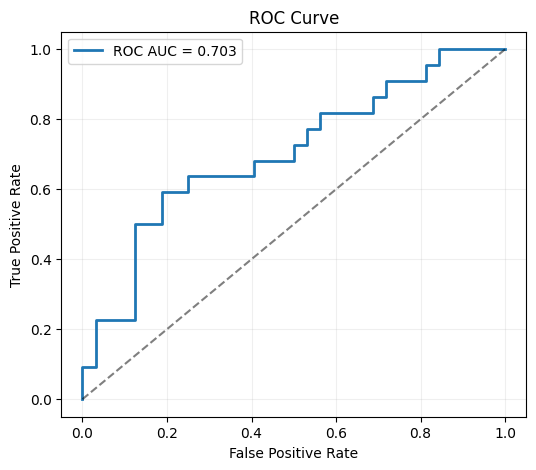

In [8]:
plt.figure(figsize=(6, 5))

if len(np.unique(y_true)) > 1:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC AUC = {metrics['roc_auc']:.3f}")
else:
    plt.plot([0, 1], [0, 1], "k--", label="Insufficient class diversity")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

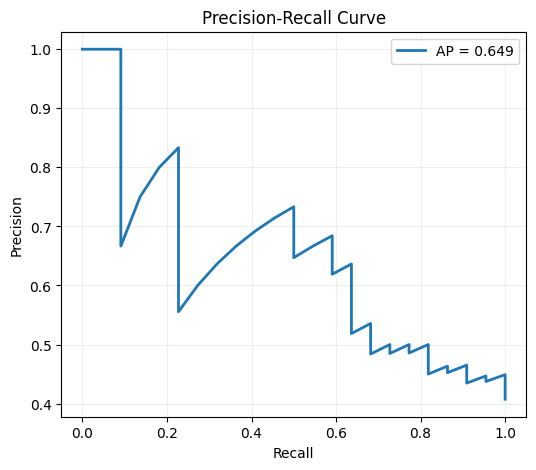

In [9]:
plt.figure(figsize=(6, 5))

if len(np.unique(y_true)) > 1:
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    plt.plot(rec, prec, linewidth=2, label=f"AP = {metrics['avg_precision']:.3f}")
else:
    plt.plot([0, 1], [np.mean(y_true), np.mean(y_true)], "k--",
             label="Insufficient class diversity")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

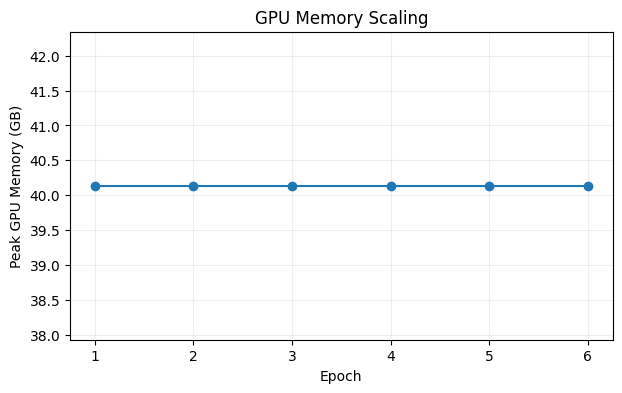

In [10]:
epochs_axis = np.arange(1, len(gpu_peak_mem_gb) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_axis, gpu_peak_mem_gb, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Peak GPU Memory (GB)")
plt.title("GPU Memory Scaling")
plt.grid(alpha=0.2)
plt.show()

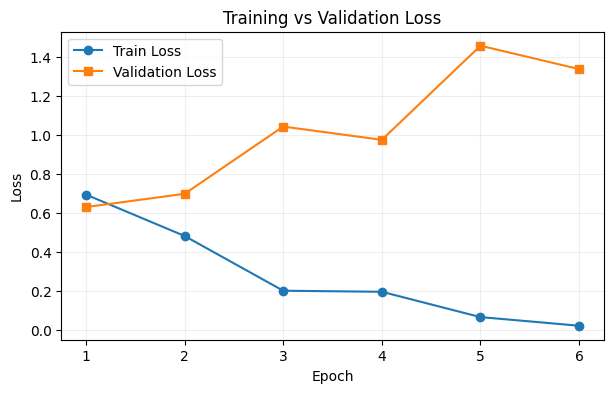

In [11]:
plt.figure(figsize=(7, 4))

plt.plot(epochs_axis, train_losses, marker="o", label="Train Loss")
plt.plot(epochs_axis, val_losses, marker="s", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.show()